# Section 2 – Cancellation Analysis

The objective of this analysis is to identify the main drivers of booking cancellations and recommend targeted actions that can help reduce the platform-wide cancellation rate from 19% to 14%.

The analysis is structured in four parts:

1. A1 – Explore cancellation patterns across cities and months
2. A2 – Identify the highest-risk cancellation segments
3. A3 – Root cause analysis
4. A4 – Recommendation and impact estimation

In [1]:
# Load and clean
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

# IMPORTANT: keep_default_na=False prevents 'None' loyalty tier from disappearing
df_raw = pd.read_csv('hotel_bookings (1).csv', keep_default_na=False)

df = df_raw.copy()

# Convert date columns
df['checkin_date']  = pd.to_datetime(df['checkin_date'],  errors='coerce')
df['checkout_date'] = pd.to_datetime(df['checkout_date'], errors='coerce')
df['booking_date']  = pd.to_datetime(df['booking_date'],  errors='coerce')

# Remove invalid stays (checkout <= checkin) — Footnote 1
df = df[df['checkout_date'] > df['checkin_date']]

# Remove zero-room rows — Footnote 3
df = df[df['num_rooms'] > 0]

# Keep only Completed, Cancelled, No-Show
df = df[df['booking_status'].isin(['Completed', 'Cancelled', 'No-Show'])]

# Booking-before-signup rows are KEPT (per instructions)

print(f"Raw rows: {len(df_raw)}")
print(f"Clean rows: {len(df)}")
print(df['booking_status'].value_counts())

Raw rows: 12000
Clean rows: 11821
booking_status
Completed    9198
Cancelled    2264
No-Show       359
Name: count, dtype: int64


In [2]:
# Derived columns needed throughout
df['is_cancelled']       = (df['booking_status'] == 'Cancelled').astype(int)
df['lead_time']          = (df['checkin_date'] - df['booking_date']).dt.days
df['checkin_month']      = df['checkin_date'].dt.month
df['checkin_month_name'] = df['checkin_date'].dt.strftime('%b')

month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

In [3]:
# Overall cancellation rate
overall_rate = df['is_cancelled'].mean() * 100
print(f"Overall cancellation rate: {overall_rate:.2f}%")

Overall cancellation rate: 19.15%


# A1 – Cancellation Landscape

To understand where cancellations are concentrated, cancellation rates are analyzed across both property city and check-in month.

The objective is to identify unusual hotspots that may require deeper investigation.

The heatmap below shows cancellation rates for every city-month combination.

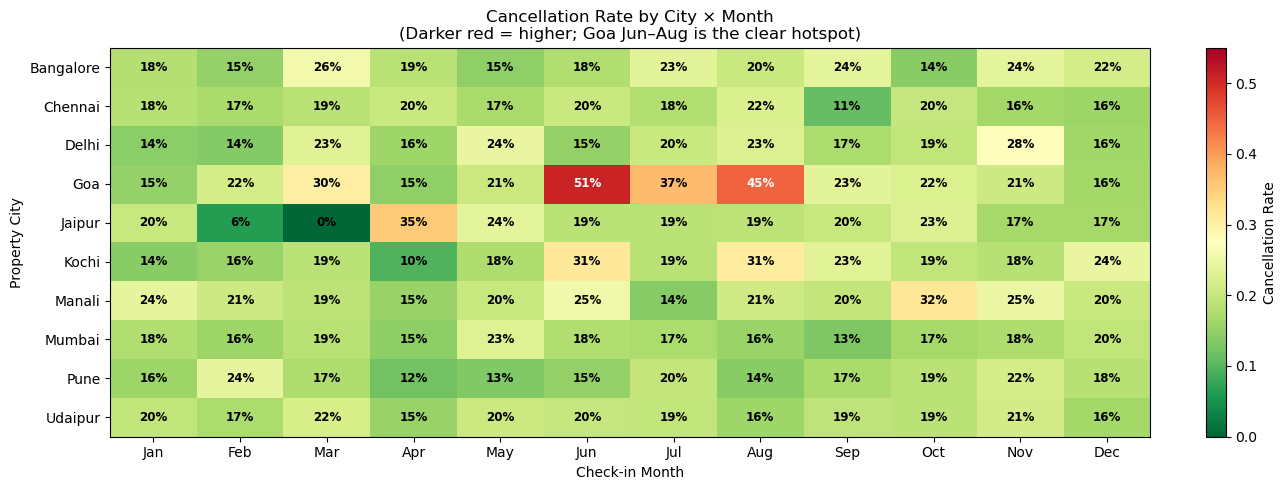

In [4]:
# City × Month heatmap
city_month = df.groupby(['property_city', 'checkin_month_name'])['is_cancelled'].mean().unstack()
city_month = city_month[[m for m in month_order if m in city_month.columns]]

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(
    city_month.values,
    cmap='RdYlGn_r',
    aspect='auto',
    vmin=0,
    vmax=0.55,
    interpolation='nearest'
)

ax.set_xticks(range(len(city_month.columns)))
ax.set_xticklabels(city_month.columns)
ax.set_yticks(range(len(city_month.index)))
ax.set_yticklabels(city_month.index)

# Add percentage labels inside each cell
for i in range(len(city_month.index)):
    for j in range(len(city_month.columns)):
        val = city_month.values[i, j]
        if not np.isnan(val):
            color = 'white' if val > 0.38 else 'black'
            ax.text(j, i, f'{val*100:.0f}%', ha='center', va='center', fontsize=8.5,
                    color=color, fontweight='bold')

fig.colorbar(im, ax=ax, fraction=0.025).set_label('Cancellation Rate')
ax.set_title('Cancellation Rate by City × Month\n(Darker red = higher; Goa Jun–Aug is the clear hotspot)')
ax.set_xlabel('Check-in Month')
ax.set_ylabel('Property City')
plt.tight_layout()
plt.savefig("A1_Heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### A1 – Key Findings

Cancellation behaviour is not evenly distributed across the platform.

Several city-month combinations exhibit elevated cancellation rates, with Goa during the monsoon period standing out as a particularly high-risk segment.

These patterns suggest that cancellations may be driven by specific customer, channel, or seasonal effects rather than a platform-wide issue.

The next step is to identify which segments contribute the most cancellations.

# A2 – Identifying High-Risk Segments

High cancellation rate and high cancellation volume are different business problems.

A segment with a high cancellation rate may not materially affect the platform if it represents a small number of bookings. Conversely, a large segment can generate substantial cancellations even if its rate is only moderately elevated.

To support the board's objective, both perspectives are examined:

- Highest cancellation rate
- Highest cancellation volume

In [5]:
# Cancellation contribution by City × Channel
total_cancels = df['is_cancelled'].sum()
print("Total cancellations:", total_cancels)
city_chan = df.groupby(['property_city', 'booking_channel']).agg(
    bookings       = ('is_cancelled', 'count'),
    cancellations  = ('is_cancelled', 'sum'),
    cancel_rate    = ('is_cancelled', 'mean')
).reset_index()

city_chan = city_chan[city_chan['bookings'] >= 30]
city_chan['pct_of_all_cancels'] = city_chan['cancellations'] / total_cancels * 100
city_chan['cancel_rate_pct']    = city_chan['cancel_rate'] * 100

print("Top 3 by RATE:")
print(city_chan.nlargest(3, 'cancel_rate')[['property_city','booking_channel','cancellations','cancel_rate_pct','pct_of_all_cancels']])

print("\nTop 3 by VOLUME:")
print(city_chan.nlargest(3, 'cancellations')[['property_city','booking_channel','cancellations','cancel_rate_pct','pct_of_all_cancels']])

Total cancellations: 2264
Top 3 by RATE:
   property_city   booking_channel  cancellations  cancel_rate_pct  \
14           Goa               OTA             90        28.846154   
12           Goa  Corporate Portal             59        26.940639   
18        Jaipur               OTA             23        25.555556   

    pct_of_all_cancels  
14            3.975265  
12            2.606007  
18            1.015901  

Top 3 by VOLUME:
   property_city booking_channel  cancellations  cancel_rate_pct  \
2      Bangalore             OTA            145        25.043178   
6        Chennai             OTA            134        18.953324   
34          Pune             OTA            132        20.245399   

    pct_of_all_cancels  
2             6.404594  
6             5.918728  
34            5.830389  


In [6]:
#  Top 3 by CANCELLATION RATE
print("Top 3 slices by cancellation RATE:")
top_by_rate = city_chan.nlargest(3, 'cancel_rate_pct')[
    ['property_city', 'booking_channel', 'bookings', 'cancellations', 'cancel_rate_pct', 'pct_of_all_cancels']
].reset_index(drop=True)
print(top_by_rate.to_string(index=False))

Top 3 slices by cancellation RATE:
property_city  booking_channel  bookings  cancellations  cancel_rate_pct  pct_of_all_cancels
          Goa              OTA       312             90        28.846154            3.975265
          Goa Corporate Portal       219             59        26.940639            2.606007
       Jaipur              OTA        90             23        25.555556            1.015901


In [7]:
# Top 3 by CANCELLATION COUNT
print("Top 3 slices by cancellation COUNT:")
top_by_count = city_chan.nlargest(3, 'cancellations')[
    ['property_city', 'booking_channel', 'bookings', 'cancellations', 'cancel_rate_pct', 'pct_of_all_cancels']
].reset_index(drop=True)
print(top_by_count.to_string(index=False))

Top 3 slices by cancellation COUNT:
property_city booking_channel  bookings  cancellations  cancel_rate_pct  pct_of_all_cancels
    Bangalore             OTA       579            145        25.043178            6.404594
      Chennai             OTA       707            134        18.953324            5.918728
         Pune             OTA       652            132        20.245399            5.830389


### A2 – Key Findings

OTA bookings appear repeatedly among both the highest-rate and highest-volume cancellation segments.

While Goa OTA bookings exhibit the highest cancellation rate, OTA bookings in Bangalore, Chennai, and Pune contribute the largest number of cancellations due to their scale.

This pattern suggests that booking channel may be a more important driver of cancellations than geography alone.

The next section investigates the root causes behind the elevated OTA cancellation rate.

## A3 – Root Cause Analysis

A2 showed that OTA bookings appear repeatedly among both the highest-rate and highest-volume cancellation segments.

To understand whether OTA cancellations are driven by customer behaviour, geography, or seasonality, three hypotheses are tested below.

This section tests three possible explanations:

1. Lead-Time Effect
2. Channel-Mix Effect
3. City-and-Season Effect

The goal is to identify which factor best explains the unusually high cancellation rate.

In [8]:
# Define OTA slice vs rest
ota_df     = df[df['booking_channel'] == 'OTA'].copy()
non_ota_df = df[df['booking_channel'] != 'OTA'].copy()

print(f"OTA:     {len(ota_df)} bookings, {ota_df['is_cancelled'].mean()*100:.1f}% cancel rate, {ota_df['is_cancelled'].sum()} cancels")
print(f"Non-OTA: {len(non_ota_df)} bookings, {non_ota_df['is_cancelled'].mean()*100:.1f}% cancel rate, {non_ota_df['is_cancelled'].sum()} cancels")

OTA:     4184 bookings, 22.0% cancel rate, 919 cancels
Non-OTA: 7637 bookings, 17.6% cancel rate, 1345 cancels


In [9]:
#  Lead-time bucket comparison: OTA vs non-OTA
def lead_bucket(x):
    if pd.isna(x): return 'Unknown'
    if x <= 7:    return '0-7d'
    elif x <= 30: return '8-30d'
    elif x <= 90: return '31-90d'
    else:         return '90+d'

ota_df['lt_bucket']     = ota_df['lead_time'].apply(lead_bucket)
non_ota_df['lt_bucket'] = non_ota_df['lead_time'].apply(lead_bucket)
bucket_order = ['0-7d', '8-30d', '31-90d', '90+d']

# Cancel rate by bucket
lt_compare = pd.DataFrame({
    'OTA rate (%)':     ota_df.groupby('lt_bucket')['is_cancelled'].mean().reindex(bucket_order) * 100,
    'Non-OTA rate (%)': non_ota_df.groupby('lt_bucket')['is_cancelled'].mean().reindex(bucket_order) * 100,
    'OTA cancels':      ota_df.groupby('lt_bucket')['is_cancelled'].sum().reindex(bucket_order),
    'OTA bookings':     ota_df.groupby('lt_bucket')['is_cancelled'].count().reindex(bucket_order),
}).round(1)
print(lt_compare)

# Median lead time comparison
print(f"\nOTA median lead time:     {ota_df['lead_time'].median():.0f} days")
print(f"Non-OTA median lead time: {non_ota_df['lead_time'].median():.0f} days")

           OTA rate (%)  Non-OTA rate (%)  OTA cancels  OTA bookings
lt_bucket                                                           
0-7d               20.3              16.1          279          1375
8-30d              19.5              16.1          291          1496
31-90d             26.8              21.3          341          1271
90+d               19.0              17.9            8            42

OTA median lead time:     15 days
Non-OTA median lead time: 15 days


#### Chart 1 – Lead-Time Comparison

This chart compares cancellation rates across lead-time buckets for OTA and Non-OTA bookings.

If lead time is the primary driver of cancellations, we would expect large differences across lead-time buckets. If the gap remains relatively consistent across buckets, lead time alone is unlikely to explain the cancellation pattern.

<function matplotlib.pyplot.show(close=None, block=None)>

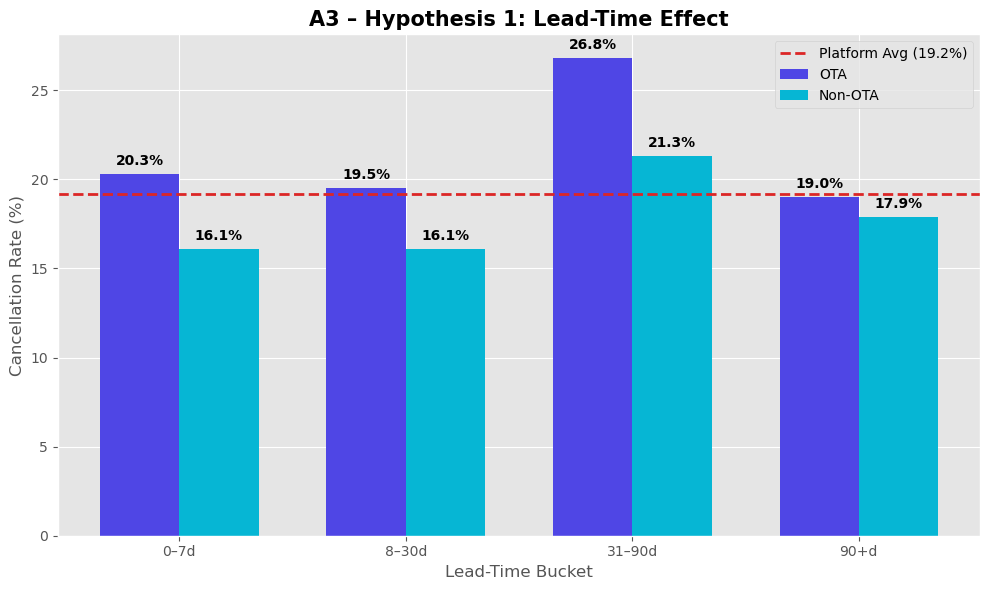

In [10]:
# Chart 1 – H1: Lead-Time Effect

import matplotlib.pyplot as plt
import numpy as np

plt.style.use('ggplot')

bucket_order = ['0–7d', '8–30d', '31–90d', '90+d']

ota_rates = lt_compare['OTA rate (%)']
non_ota_rates = lt_compare['Non-OTA rate (%)']

x = np.arange(len(bucket_order))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))

bars1 = ax.bar(
    x - width/2,
    ota_rates,
    width,
    color='#4F46E5',   # Indigo
    label='OTA'
)

bars2 = ax.bar(
    x + width/2,
    non_ota_rates,
    width,
    color='#06B6D4',   # Cyan
    label='Non-OTA'
)

for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}%',
        ha='center',
        fontweight='bold'
    )

for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,
        f'{bar.get_height():.1f}%',
        ha='center',
        fontweight='bold'
    )

platform_avg = df['is_cancelled'].mean() * 100

ax.axhline(
    platform_avg,
    color='#DC2626',   # Red
    linestyle='--',
    linewidth=2,
    label=f'Platform Avg ({platform_avg:.1f}%)'
)

ax.set_xticks(x)
ax.set_xticklabels(bucket_order)

ax.set_title(
    'A3 – Hypothesis 1: Lead-Time Effect',
    fontsize=15,
    fontweight='bold'
)

ax.set_ylabel('Cancellation Rate (%)')
ax.set_xlabel('Lead-Time Bucket')

ax.legend()

plt.tight_layout()
plt.savefig("A3_H1.png", dpi=300, bbox_inches="tight")
plt.show


**Interpretation**

OTA bookings show higher cancellation rates than Non-OTA bookings across every lead-time bucket.

The largest difference appears in the 31–90 day bucket, where OTA cancellations are noticeably higher than Non-OTA cancellations.

However, the OTA premium exists across all lead-time groups rather than being concentrated in a single bucket. This suggests that lead time alone does not fully explain the higher cancellation rate observed for OTA bookings.

**Verdict**

Hypothesis 1 is only partially supported.

Lead time influences cancellation behaviour, but it is not the primary driver of the OTA cancellation gap. Additional factors must be contributing to the higher cancellation rates observed in OTA bookings.

### Hypothesis 2 – Channel-Mix Effect

Hypothesis: OTA's higher cancellation rate is driven by one or two city outliers pulling the average upward.

To test this, OTA cancellation performance is compared across all cities. If only a few cities are responsible for the elevated rate, the problem is geographic. If the pattern appears across most cities, the issue is likely structural to the OTA channel itself.

In [11]:
#  OTA cancel rate across all cities
ota_city = ota_df.groupby('property_city').agg(
    bookings      = ('is_cancelled', 'count'),
    cancellations = ('is_cancelled', 'sum'),
    cancel_rate   = ('is_cancelled', 'mean')
).reset_index()
ota_city['cancel_rate_pct'] = (ota_city['cancel_rate'] * 100).round(1)
ota_city = ota_city.sort_values('cancellations', ascending=False)
print(ota_city[['property_city', 'bookings', 'cancellations', 'cancel_rate_pct']])

# Channel-level rates for comparison
print("\nCancel rate by channel:")
print(df.groupby('booking_channel')['is_cancelled'].mean().mul(100).round(1).sort_values(ascending=False))

  property_city  bookings  cancellations  cancel_rate_pct
0     Bangalore       579            145             25.0
1       Chennai       707            134             19.0
8          Pune       652            132             20.2
9       Udaipur       532            117             22.0
7        Mumbai       494            101             20.4
3           Goa       312             90             28.8
6        Manali       270             67             24.8
2         Delhi       282             56             19.9
5         Kochi       266             54             20.3
4        Jaipur        90             23             25.6

Cancel rate by channel:
booking_channel
OTA                 22.0
Corporate Portal    20.2
Travel Agent        16.7
Direct Website      14.8
Name: is_cancelled, dtype: float64


#### Chart 2 – OTA Cancellation Rate by City

This chart evaluates whether OTA's higher cancellation rate is concentrated in a small number of cities or remains elevated across the network.

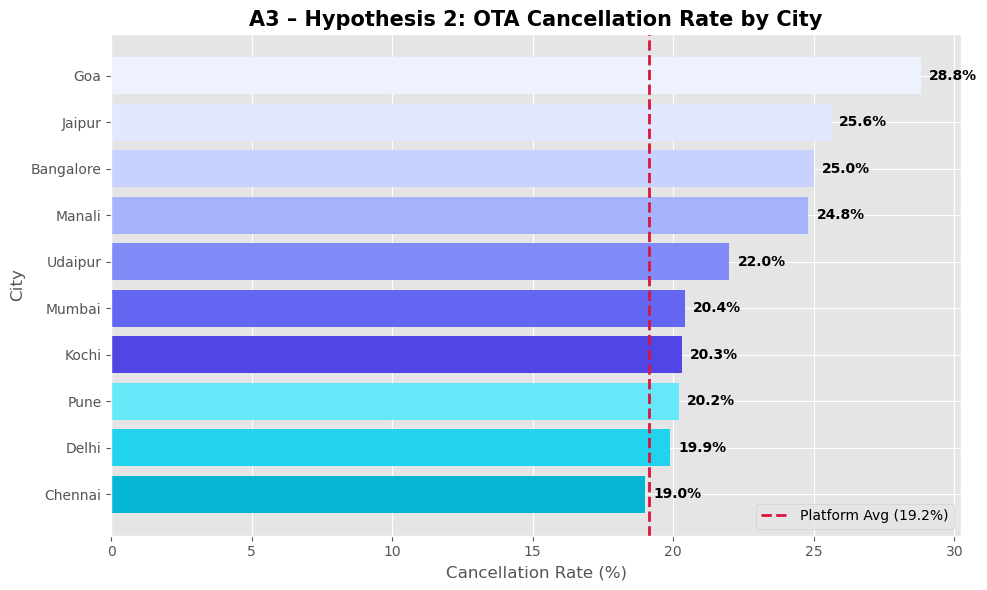

In [12]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('ggplot')

city_plot = ota_city.sort_values(
    'cancel_rate_pct',
    ascending=True
)

colors = [
    '#06B6D4',
    '#22D3EE',
    '#67E8F9',
    '#4F46E5',
    '#6366F1',
    '#818CF8',
    '#A5B4FC',
    '#C7D2FE',
    '#E0E7FF',
    '#EEF2FF'
]


fig, ax = plt.subplots(figsize=(10,6))

bars = ax.barh(
    city_plot['property_city'],
    city_plot['cancel_rate_pct'],
    color=colors
)

for bar in bars:
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.1f}%",
        va='center',
        fontweight='bold'
    )

platform_avg = df['is_cancelled'].mean() * 100

ax.axvline(
    platform_avg,
    color='crimson',
    linestyle='--',
    linewidth=2,
    label=f'Platform Avg ({platform_avg:.1f}%)'
)

ax.set_title(
    'A3 – Hypothesis 2: OTA Cancellation Rate by City',
    fontsize=15,
    fontweight='bold'
)

ax.set_xlabel('Cancellation Rate (%)')
ax.set_ylabel('City')

ax.legend()

plt.tight_layout()
plt.savefig("A3_H2.png", dpi=300, bbox_inches="tight")
plt.show()


**Interpretation**

OTA cancellation rates remain elevated across most cities.

Although Goa, Bangalore and Jaipur show particularly high rates, the pattern is not driven by a single city. OTA cancellations exceed the platform average in multiple locations, suggesting the issue is broader than a geographic hotspot.

**Verdict**

Hypothesis 2 is not supported.

OTA's elevated cancellation rate is not caused by one or two cities pulling up the average. The pattern appears across the network, indicating that the issue is structural to the OTA channel.

### Hypothesis 3 – City-and-Season Effect

Hypothesis: OTA's higher cancellation rate is driven by specific seasonal patterns.

To test this, OTA and Non-OTA cancellation rates are compared across months. If OTA's advantage disappears outside a few months, seasonality may explain the gap. If the difference remains visible throughout the year, the issue is likely persistent rather than seasonal.

In [13]:
#  OTA vs non-OTA cancel rate by month
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

ota_month = (ota_df.groupby('checkin_month_name')['is_cancelled'].mean()
             .reindex([m for m in month_order if m in ota_df['checkin_month_name'].values]) * 100)
non_ota_month = (non_ota_df.groupby('checkin_month_name')['is_cancelled'].mean()
                 .reindex([m for m in month_order if m in non_ota_df['checkin_month_name'].values]) * 100)

print("OTA cancel rate by month:")
print(ota_month.round(1))
print("\nNon-OTA cancel rate by month:")
print(non_ota_month.round(1))

# OTA vs Direct Website rate by city (structural gap test)
gap_check = df.groupby(['booking_channel', 'property_city'])['is_cancelled'].mean().unstack()
gap_check = gap_check.loc[['OTA', 'Direct Website']].T * 100
gap_check['gap (pp)'] = gap_check['OTA'] - gap_check['Direct Website']
print("\nOTA vs Direct Website gap by city:")
print(gap_check.round(1))

OTA cancel rate by month:
checkin_month_name
Jan    20.9
Feb    18.9
Mar    25.0
Apr    16.4
May    20.4
Jun    24.6
Jul    24.1
Aug    24.2
Sep    22.2
Oct    22.5
Nov    23.1
Dec    21.3
Name: is_cancelled, dtype: float64

Non-OTA cancel rate by month:
checkin_month_name
Jan    15.4
Feb    17.3
Mar    17.4
Apr    15.6
May    17.3
Jun    19.3
Jul    18.4
Aug    20.0
Sep    16.1
Oct    17.7
Nov    19.5
Dec    17.1
Name: is_cancelled, dtype: float64

OTA vs Direct Website gap by city:
booking_channel   OTA  Direct Website  gap (pp)
property_city                                  
Bangalore        25.0            10.6      14.5
Chennai          19.0            14.0       5.0
Delhi            19.9            20.1      -0.3
Goa              28.8            22.9       5.9
Jaipur           25.6            12.8      12.7
Kochi            20.3            16.8       3.5
Manali           24.8            15.2       9.6
Mumbai           20.4            10.1      10.4
Pune             20.2          

#### Chart 3 – OTA vs Non-OTA Cancellation Rate by Month

This chart compares monthly cancellation rates for OTA and Non-OTA bookings to determine whether the OTA effect is concentrated in specific periods of the year.

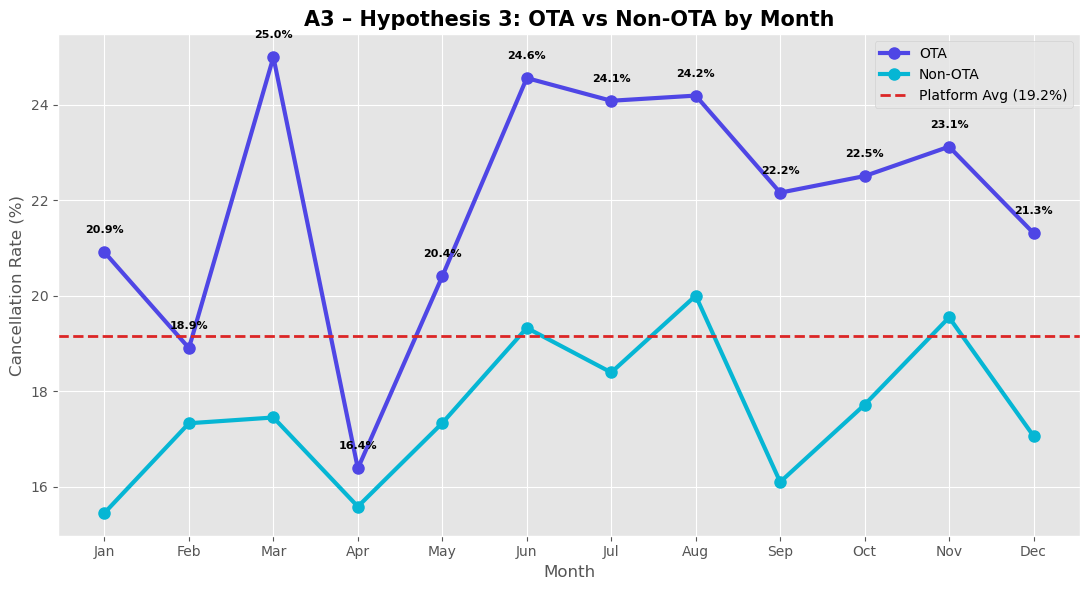

In [14]:
import matplotlib.pyplot as plt

plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(11,6))

ax.plot(
    ota_month.index,
    ota_month.values,
    marker='o',
    markersize=8,
    linewidth=3,
    color='#4F46E5',
    label='OTA'
)

ax.plot(
    non_ota_month.index,
    non_ota_month.values,
    marker='o',
    markersize=8,
    linewidth=3,
    color='#06B6D4',
    label='Non-OTA'
)

for i, v in enumerate(ota_month.values):
    ax.text(
        i,
        v + 0.4,
        f'{v:.1f}%',
        ha='center',
        fontsize=8,
        fontweight='bold'
    )

platform_avg = df['is_cancelled'].mean() * 100

ax.axhline(
    platform_avg,
    color='#DC2626',
    linestyle='--',
    linewidth=2,
    label=f'Platform Avg ({platform_avg:.1f}%)'
)

ax.set_title(
    'A3 – Hypothesis 3: OTA vs Non-OTA by Month',
    fontsize=15,
    fontweight='bold'
)

ax.set_ylabel('Cancellation Rate (%)')
ax.set_xlabel('Month')

ax.legend()

plt.tight_layout()
plt.savefig("A3_H3.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretation**

OTA bookings maintain a higher cancellation rate than Non-OTA bookings throughout most months of the year.

While the size of the gap varies slightly across seasons, no single month explains the difference. OTA remains consistently higher than Non-OTA across the calendar.

**Verdict**

Hypothesis 3 is not supported.

The OTA cancellation gap is not driven by seasonality. The pattern persists throughout the year, suggesting a structural difference between OTA and Non-OTA bookings.

### Which Hypothesis Wins?

| Hypothesis | Evidence | Verdict |
|------------|-----------|----------|
| H1: Lead-Time Effect | Identical median lead time (15d); OTA elevated across all buckets; 31–90 day bucket is worst |  Partial - helps identify which OTA customers to target, but does not fully explain why OTA is higher |
| H2: Channel-Mix Effect | OTA elevated across all cities; not driven by one geographic outlier |  Ruled out |
| H3: City-and-Season Effect | OTA elevated across most months; gap vs Non-OTA remains visible throughout the year |  Ruled out |
| Structural Channel Behaviour | OTA cancellation rate consistently exceeds Direct Website across cities and months |  Best supported |

The evidence suggests that the OTA cancellation problem is structural rather than seasonal or geographic. Customers booking through OTA channels appear more likely to cancel regardless of city or month.

The 31–90 day lead-time bucket represents the highest-priority sub-segment because it combines a high cancellation rate with a meaningful number of cancellations.

### A3 Conclusion

The analysis suggests that OTA bookings consistently experience higher cancellation rates than Non-OTA bookings.

Lead time influences cancellation behaviour but does not fully explain the gap.

The higher OTA cancellation rate is not driven by a small number of cities and is not concentrated in specific months. The pattern remains visible across locations and throughout the year.

This indicates that the OTA channel itself is the strongest contributor to elevated cancellations and should be the primary focus of any intervention.

## A4 – Targeted Recommendation

The root cause analysis indicates that OTA bookings are the largest and most consistent contributor to cancellations.

This section evaluates potential interventions, estimates their impact, and assesses how much progress they can make toward the board's target of reducing cancellations from approximately 19% to 14%.

In [15]:
#  Define the need and target group
total_bookings = len(df)
total_cancels  = df['is_cancelled'].sum()
overall_rate   = total_cancels / total_bookings

need_to_prevent = int(total_cancels - 0.14 * total_bookings)
print(f"Platform cancel rate:  {overall_rate*100:.2f}%")
print(f"Board target:          14.00%")
print(f"Cancels to prevent:    {need_to_prevent}")

# Primary target: OTA 31-90d lead-time bucket
ota_31_90 = ota_df[ota_df['lt_bucket'] == '31-90d']
print(f"\nPrimary target — OTA 31-90d:")
print(f"  Bookings:      {len(ota_31_90)}")
print(f"  Cancellations: {ota_31_90['is_cancelled'].sum()}")
print(f"  Cancel rate:   {ota_31_90['is_cancelled'].mean()*100:.1f}%")

Platform cancel rate:  19.15%
Board target:          14.00%
Cancels to prevent:    609

Primary target — OTA 31-90d:
  Bookings:      1271
  Cancellations: 341
  Cancel rate:   26.8%


## Intervention Scenarios

To determine the most effective policy, multiple intervention scenarios are evaluated.

Each scenario estimates:
- Number of cancellations prevented
- New platform-wide cancellation rate
- Percentage-point reduction versus the current rate

This allows direct comparison of different policy options against the board's target of reducing cancellations from approximately 19% to 14%.

In [16]:
#  Impact calculation for each scenario
ota_all = ota_df
cp_all  = df[df['booking_channel'] == 'Corporate Portal']

print("=== SCENARIO CALCULATIONS ===\n")

# Scenario 1: OTA 31-90d only → reduce to 18% (conservative)
target_31_90 = 0.18
prev_1 = int(len(ota_31_90) * (ota_31_90['is_cancelled'].mean() - target_31_90))
rate_1 = (total_cancels - prev_1) / total_bookings
print(f"Scenario 1 — OTA 31-90d → 18%:")
print(f"  Prevented: {prev_1} | New rate: {rate_1*100:.2f}% | Reduction: {(overall_rate-rate_1)*100:.2f} pp\n")

# Scenario 2: All OTA → 17%
prev_2 = int(len(ota_all) * (ota_all['is_cancelled'].mean() - 0.17))
rate_2 = (total_cancels - prev_2) / total_bookings
print(f"Scenario 2 — All OTA → 17%:")
print(f"  Prevented: {prev_2} | New rate: {rate_2*100:.2f}% | Reduction: {(overall_rate-rate_2)*100:.2f} pp\n")

# Scenario 3: All OTA → 15%
prev_3 = int(len(ota_all) * (ota_all['is_cancelled'].mean() - 0.15))
rate_3 = (total_cancels - prev_3) / total_bookings
print(f"Scenario 3 — All OTA → 15%:")
print(f"  Prevented: {prev_3} | New rate: {rate_3*100:.2f}% | Reduction: {(overall_rate-rate_3)*100:.2f} pp\n")

# Scenario 4: OTA + Corporate Portal both → 17% (stacked)
prev_4_ota = int(len(ota_all) * (ota_all['is_cancelled'].mean() - 0.17))
prev_4_cp  = int(len(cp_all)  * (cp_all['is_cancelled'].mean()  - 0.17))
prev_4     = prev_4_ota + prev_4_cp
rate_4     = (total_cancels - prev_4) / total_bookings
print(f"Scenario 4 — OTA + Corporate Portal → 17% (stacked):")
print(f"  OTA prevented: {prev_4_ota} | CP prevented: {prev_4_cp} | Total: {prev_4}")
print(f"  New rate: {rate_4*100:.2f}% | Reduction: {(overall_rate-rate_4)*100:.2f} pp\n")

# Goa monsoon (original) for comparison
goa_ota_ta = df[(df['property_city']=='Goa') & (df['checkin_month'].isin([6,7,8])) &
                (df['booking_channel'].isin(['OTA','Travel Agent']))]
prev_orig = int(len(goa_ota_ta) * (goa_ota_ta['is_cancelled'].mean() - 0.206))
rate_orig = (total_cancels - prev_orig) / total_bookings
print(f"Original rec — Goa monsoon OTA+TA → 20.6%:")
print(f"  Prevented: {prev_orig} | New rate: {rate_orig*100:.2f}% | Reduction: {(overall_rate-rate_orig)*100:.2f} pp")

=== SCENARIO CALCULATIONS ===

Scenario 1 — OTA 31-90d → 18%:
  Prevented: 112 | New rate: 18.20% | Reduction: 0.95 pp

Scenario 2 — All OTA → 17%:
  Prevented: 207 | New rate: 17.40% | Reduction: 1.75 pp

Scenario 3 — All OTA → 15%:
  Prevented: 291 | New rate: 16.69% | Reduction: 2.46 pp

Scenario 4 — OTA + Corporate Portal → 17% (stacked):
  OTA prevented: 207 | CP prevented: 100 | Total: 307
  New rate: 16.56% | Reduction: 2.60 pp

Original rec — Goa monsoon OTA+TA → 20.6%:
  Prevented: 34 | New rate: 18.86% | Reduction: 0.29 pp


In [17]:
# Print the gap-to-target summary
print(f"Board needs: 5.15 pp reduction ({need_to_prevent} fewer cancels)")
print(f"Best single intervention (OTA→15%): 2.46 pp  →  {int((2.46/5.15)*100)}% of target")
print(f"Stacked (OTA+CP→17%):              2.60 pp  →  {int((2.60/5.15)*100)}% of target")
print(f"Remaining gap after stacking:      {5.15-2.60:.2f} pp — needs additional levers")

Board needs: 5.15 pp reduction (609 fewer cancels)
Best single intervention (OTA→15%): 2.46 pp  →  47% of target
Stacked (OTA+CP→17%):              2.60 pp  →  50% of target
Remaining gap after stacking:      2.55 pp — needs additional levers


## Chart 4 – Estimated Impact of Intervention Scenarios

The board's target is to reduce the platform cancellation rate from approximately 19% to 14%.

This chart compares the projected cancellation rate under each intervention scenario and shows how much progress each option makes toward the target.

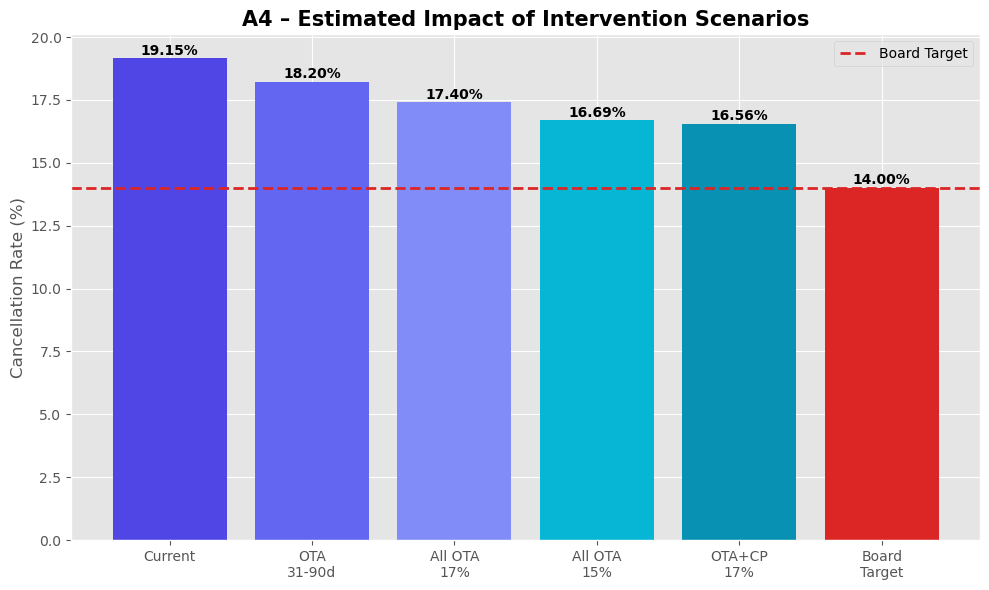

In [18]:
import matplotlib.pyplot as plt

plt.style.use('ggplot')

scenarios = [
    'Current',
    'OTA\n31-90d',
    'All OTA\n17%',
    'All OTA\n15%',
    'OTA+CP\n17%',
    'Board\nTarget'
]

rates = [
    overall_rate * 100,
    rate_1 * 100,
    rate_2 * 100,
    rate_3 * 100,
    rate_4 * 100,
    14.0
]

colors = [
    '#4F46E5',
    '#6366F1',
    '#818CF8',
    '#06B6D4',
    '#0891B2',
    '#DC2626'
]

fig, ax = plt.subplots(figsize=(10,6))

bars = ax.bar(
    scenarios,
    rates,
    color=colors
)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.15,
        f'{bar.get_height():.2f}%',
        ha='center',
        fontweight='bold'
    )

ax.axhline(
    14,
    color='#DC2626',
    linestyle='--',
    linewidth=2,
    label='Board Target'
)

ax.set_title(
    'A4 – Estimated Impact of Intervention Scenarios',
    fontsize=15,
    fontweight='bold'
)

ax.set_ylabel('Cancellation Rate (%)')

ax.legend()

plt.tight_layout()
plt.savefig("A4_Impact.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretation**

The OTA 31–90 day intervention provides a meaningful reduction in cancellations but does not achieve the board target on its own.

Expanding the intervention across all OTA bookings produces a larger improvement, reducing the platform cancellation rate to approximately 16.7%.

The strongest scenario combines OTA and Corporate Portal interventions, reducing the cancellation rate to approximately 16.6%. While this represents the largest improvement identified in the analysis, the platform would still remain above the board target of 14%.

This indicates that OTA-focused interventions are the most impactful lever available, but additional measures would be required to fully close the remaining gap.

### Counterfactual

If no action is taken, the platform cancellation rate is expected to remain near 19.15%.

The strongest OTA-only intervention reduces the rate to approximately 16.69%, while the combined OTA and Corporate Portal intervention lowers it further to 16.56%.

Even the strongest identified intervention does not fully achieve the board's 14% target, indicating that additional measures would be required to close the remaining gap.

## Final Recommendation

### WHO

All OTA bookings platform-wide, prioritising the 31–90 day lead-time segment across the five highest-volume cities: Bangalore, Chennai, Pune, Udaipur, and Mumbai.

### WHAT

Introduce a tiered non-refundable deposit for OTA bookings. Customers booking 31–90 days before check-in should pay a 20–25% non-refundable deposit, while shorter lead-time bookings remain flexible.

### WHY

The OTA vs Direct Website cancellation gap (22.0% vs 14.8%) remains consistent across cities and months, indicating a structural channel effect rather than a city-specific or seasonal issue.

The 31–90 day OTA segment contains the highest concentration of cancellations (341 cancellations at a 26.8% cancellation rate), making it the most efficient segment to target.

### Expected Impact

Estimated reduction: **−1.75 to −2.46 percentage points** platform-wide.

This would reduce the overall cancellation rate from approximately **19.15% to 16.7%–17.4%** and prevent approximately **207–291 cancellations**.

### Risk

OTA partners may resist deposit requirements or customers may shift toward competitors offering more flexible cancellation policies.

A pilot rollout in a small number of high-volume cities is recommended before platform-wide implementation.